# Project : Impact of Sample Processing (Fresh vs. Fixed vs. Fixed-Stored) on Single-Cell Transcriptomic Profiling of Diseased PBMCs in Primary Myelofibrosis

### Section 1: Import Library and Load Data

In [2]:
!pip install 'scanpy[leiden]' 'pandas>=3.0'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scanpy as sc
import anndata as ad

print(f"pandas: {pd.__version__}")  # Should show 3.x


pandas: 3.0.3


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = '/content/drive/MyDrive/PBMC/'

In [6]:
# Set path to your PBMC files in Google Drive
path = '/content/drive/MyDrive/PBMC/'  # ← Update this to your actual path

# Load all three datasets
adata_fresh = sc.read_10x_h5(path + '10k_3p_Human_diseased_PBMC_Myelofibrosis_Fresh_count_filtered_feature_bc_matrix.h5')
adata_fix = sc.read_10x_h5(path + '10k_3p_Human_diseased_PBMC_Myelofibrosis_Fix_count_filtered_feature_bc_matrix.h5')
adata_stored = sc.read_10x_h5(path + '10k_3p_Human_diseased_PBMC_Myelofibrosis_Fix_stored_count_filtered_feature_bc_matrix.h5')

# Fix duplicate gene names immediately
adata_fresh.var_names_make_unique()
adata_fix.var_names_make_unique()
adata_stored.var_names_make_unique()

print("✅ Loaded successfully")
print(f"  Fresh:        {adata_fresh.shape}")
print(f"  Fixed:        {adata_fix.shape}")
print(f"  Fixed_Stored: {adata_stored.shape}")


/usr/local/lib/python3.12/dist-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()
/usr/local/lib/python3.12/dist-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


✅ Loaded successfully
  Fresh:        (12516, 38606)
  Fixed:        (11538, 38606)
  Fixed_Stored: (5825, 38606)


/usr/local/lib/python3.12/dist-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


In [7]:
# Label each dataset with its condition
adata_fresh.obs['condition'] = 'Fresh'
adata_fix.obs['condition'] = 'Fixed'
adata_stored.obs['condition'] = 'Fixed_Stored'

In [8]:
# Shape check
print("=== Dataset Shapes ===")
print(f"Fresh:        {adata_fresh.shape[0]:,} cells × {adata_fresh.shape[1]:,} genes")
print(f"Fixed:        {adata_fix.shape[0]:,} cells × {adata_fix.shape[1]:,} genes")
print(f"Fixed_Stored: {adata_stored.shape[0]:,} cells × {adata_stored.shape[1]:,} genes")

# Gene names match?
print(f"\nGenes match (Fresh vs Fixed): {(adata_fresh.var_names == adata_fix.var_names).all()}")
print(f"Genes match (Fresh vs Stored): {(adata_fresh.var_names == adata_stored.var_names).all()}")

# Preview obs
print("\n=== .obs columns ===")
print(list(adata_fresh.obs.columns))
display(adata_fresh.obs.head(3))

# Preview var
print("\n=== .var (first 5 genes) ===")
display(adata_fresh.var.head())


=== Dataset Shapes ===
Fresh:        12,516 cells × 38,606 genes
Fixed:        11,538 cells × 38,606 genes
Fixed_Stored: 5,825 cells × 38,606 genes

Genes match (Fresh vs Fixed): True
Genes match (Fresh vs Stored): True

=== .obs columns ===
['condition']


,condition
AAACCAAAGGAATGGT-1,Fresh
AAACCAAAGGGCAGGT-1,Fresh
AAACCAAAGGTTGCCG-1,Fresh



=== .var (first 5 genes) ===


,gene_ids,feature_types,genome
DDX11L2,ENSG00000290825,Gene Expression,GRCh38
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
ENSG00000290826,ENSG00000290826,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38


In [9]:
# Make all names unique before merging
adata_fresh.obs_names_make_unique()
adata_fix.obs_names_make_unique()
adata_stored.obs_names_make_unique()

# Concatenate
adata = ad.concat(
    [adata_fresh, adata_fix, adata_stored],
    label='condition',
    keys=['Fresh', 'Fixed', 'Fixed_Stored'],
    join='inner',
    index_unique='-'
)

print(f"✅ Merged: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes")
print(f"\nCells per condition:")
print(adata.obs['condition'].value_counts())


✅ Merged: 29,879 cells × 38,606 genes

Cells per condition:
condition
Fresh           12516
Fixed           11538
Fixed_Stored     5825
Name: count, dtype: int64


### Section 2: Quality Control

In [10]:
# Mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')
# Ribosomal genes
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

# Display the first few rows of the obs dataframe to see the new metrics
adata.obs.head()

,condition,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
AAACCAAAGGAATGGT-1-Fresh,Fresh,2592,8266.0,254.0,3.072829,2604.0,31.502542
AAACCAAAGGGCAGGT-1-Fresh,Fresh,1843,5050.0,120.0,2.376238,23.0,0.455446
AAACCAAAGGTTGCCG-1-Fresh,Fresh,4741,19662.0,456.0,2.319194,2691.0,13.686297
AAACCAAAGTCAGTGC-1-Fresh,Fresh,5256,24149.0,667.0,2.762019,3038.0,12.580231
AAACCATTCACAGATT-1-Fresh,Fresh,3058,11456.0,429.0,3.744762,3422.0,29.870811


#### Visualize QC Metrics

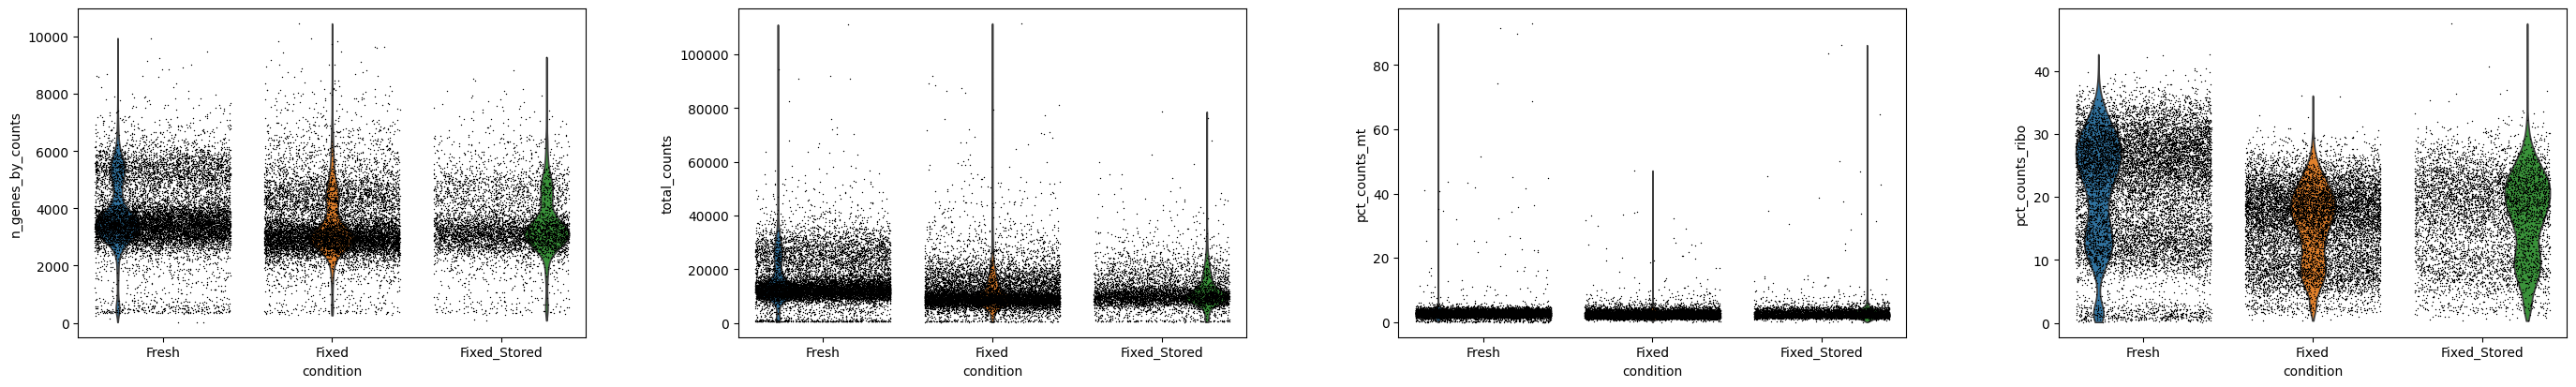

In [11]:
# Violin plots of QC metrics, grouped by condition
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
             jitter=0.4, multi_panel=True, groupby='condition')

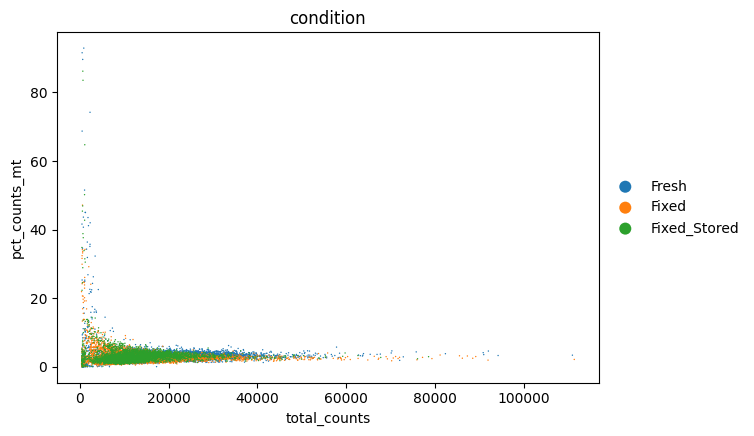

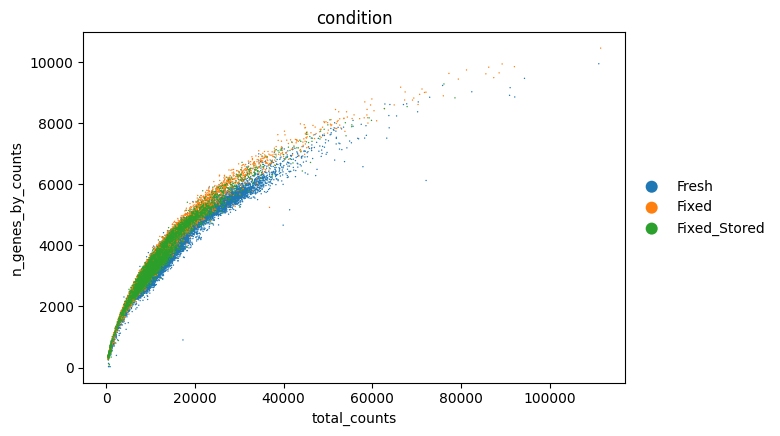

In [12]:
# Scatter plots to see the relationship between total counts, genes, and mt percentage
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', color='condition')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='condition')

#### Filter Cells and Genes

In [13]:
# Basic filtering (Adjust these thresholds based on the plots above!)
print(f"Before filtering: {adata.n_obs} cells, {adata.n_vars} genes")

# Filter cells with too few genes (empty droplets or poor quality cells)
sc.pp.filter_cells(adata, min_genes=200)

# Filter cells with too many genes (potential doublets) - adjust 4000 based on your data
adata = adata[adata.obs.n_genes_by_counts < 4000, :]

# Filter cells with high mitochondrial percentage (dead/dying cells) - adjust 10-15% based on your data
adata = adata[adata.obs.pct_counts_mt < 15, :]

# Filter genes expressed in less than 3 cells to reduce matrix size and noise
sc.pp.filter_genes(adata, min_cells=3)

print(f"After filtering: {adata.n_obs} cells, {adata.n_vars} genes")

Before filtering: 29879 cells, 38606 genes


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:280: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


After filtering: 21512 cells, 28329 genes


# Project summary

### Interpretation of Results So Far

#### Cell Recovery Across Conditions

| Condition | Cells Captured | % of Total | Interpretation |
|-----------|---------------|------------|----------------|
| Fresh | 12,516 | 41.9% | Baseline — best quality |
| Fixed | 11,538 | 38.6% | ~8% loss — fixation is relatively gentle |
| Fixed_Stored | 5,825 | 19.5% | ~50% loss — storage is destructive |

**Key finding:** Fixation alone preserves most cells (~92% survival), but long-term storage after fixation causes a **dramatic 50% cell loss**. This loss is likely **not random** — fragile cell types (monocytes, granulocytes) degrade faster than robust lymphocytes, introducing compositional bias.

#### Gene Space (38,606 genes)
All three datasets share the identical gene set (GRCh38 reference). This confirms consistent Cell Ranger processing. Most genes are zeros in any given cell (~95% sparsity), which is expected in scRNA-seq — a typical PBMC expresses only 1,000–4,000 genes.

#### QC Metrics — What They Reveal
- **`n_genes_by_counts`**: Number of genes detected per cell. Low (< 200) = empty droplet. High (> 4,000) = likely a doublet (two cells in one droplet).
- **`total_counts`**: Total UMI counts. Higher = more RNA captured = better quality. A decrease in Fixed/Stored indicates RNA degradation.
- **`pct_counts_mt`**: Mitochondrial RNA percentage. When a cell dies, its membrane breaks and cytoplasmic RNA leaks out, but mitochondrial RNA stays trapped — so dying cells show **artificially high mt%**. Threshold: < 15%.
- **`pct_counts_ribo`**: Ribosomal RNA percentage. Shifts between conditions suggest fixation differentially preserves certain RNA species.

#### Filtering Rationale

| Filter | Threshold | What It Removes |
|--------|-----------|-----------------|
| Min genes/cell | ≥ 200 | Empty droplets (ambient RNA, no real cell) |
| Max genes/cell | < 4,000 | Doublets (two cells captured together) |
| Max MT % | < 15% | Dead/dying cells with broken membranes |
| Min cells/gene | ≥ 3 | Unreliable noise genes (possible sequencing errors) |

#### Summary
The data confirms that **fixation is acceptable** for preserving PBMC transcriptomes, but **prolonged storage degrades sample quality significantly** — both in cell yield and potentially in cell type representation. The remaining analysis (clustering, differential expression, ML classification) will quantify *what specific biological information is lost* during processing.


## Further Challenges

### Can a machine tell if a cell was fresh or fixed just from its gene expression?

In [14]:
display(adata.obs.head())

,condition,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes
AAACCAAAGGAATGGT-1-Fresh,Fresh,2592,8266.0,254.0,3.072829,2604.0,31.502542,2592
AAACCAAAGGGCAGGT-1-Fresh,Fresh,1843,5050.0,120.0,2.376238,23.0,0.455446,1843
AAACCATTCACAGATT-1-Fresh,Fresh,3058,11456.0,429.0,3.744762,3422.0,29.870811,3058
AAACCCGCACATGAGT-1-Fresh,Fresh,3165,11417.0,240.0,2.102129,3309.0,28.983095,3165
AAACCCGCACCTATGC-1-Fresh,Fresh,3478,12721.0,284.0,2.232529,3080.0,24.211933,3478


In [15]:
# Convert the expression matrix X into a Pandas DataFrame
expression_df = adata.to_df()
# Show the first 5 cells and first 10 genes
display(expression_df.iloc[:5, :10])

,DDX11L2,ENSG00000238009,ENSG00000239945,ENSG00000241860,ENSG00000241599,ENSG00000286448,ENSG00000290385,ENSG00000291215,ENSG00000229905,LINC01409
AAACCAAAGGAATGGT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAAAGGGCAGGT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCATTCACAGATT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCGCACATGAGT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCGCACCTATGC-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
expression_df.head(15)

,DDX11L2,ENSG00000238009,ENSG00000239945,ENSG00000241860,ENSG00000241599,ENSG00000286448,ENSG00000290385,ENSG00000291215,ENSG00000229905,LINC01409,...,ENSG00000278704,MAFIP,ENSG00000276256,ENSG00000278384,ENSG00000273748,ENSG00000271254,ENSG00000276345,ENSG00000277856,ENSG00000275063,ENSG00000278817
AAACCAAAGGAATGGT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAAAGGGCAGGT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCATTCACAGATT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
AAACCCGCACATGAGT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
AAACCCGCACCTATGC-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
AAACCCGCATTACACT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
AAACCCTGTCAGCATT-1-Fresh,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCTGTTATGCGT-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
AAACGAATCACATGGC-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACGACAGCCACGCA-1-Fresh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
expression_df['label'] = adata.obs['condition'].values


In [16]:
import sklearn
print(sklearn.__version__)

1.6.1


In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
X = expression_df
y = adata.obs['condition']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

####
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
#####
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Label mapping: {'Fixed': np.int64(0), 'Fixed_Stored': np.int64(1), 'Fresh': np.int64(2)}
Training data shape: (17209, 28330)
Testing data shape: (4303, 28330)


In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
print("Random Forest imported successfully!")

### Which cell types survive fixation and which are lost?"

### Predict gene dropout which genes will lose signal after fixation?